# Building Data / 构建数据集

In this demo we are going to go through the process of building a custom dataset to use to train our model.

在本演示中，我们将介绍构建自定义数据集以用于训练模型的过程。

This is an example process of building data to use for model training.

这是为模型训练构建数据的示例流程。

We will cover some new concepts and best practices as well as review some concepts we have learned over the last few lessons.

我们将介绍一些新概念和最佳实践，并回顾我们在过去几课中学到的概念。

# Data Cleaning and preprocessing / 数据清理和预处理

Data cleaning and preprocessing help make sure that only clear, useful images are used to train the model, which leads to better accuracy. These steps remove any messy or confusing data so the model can learn patterns more easily.

数据清理和预处理有助于确保只有清晰有用的图像用于训练模型，这会导致更高的准确性。这些步骤删除任何混乱或令人困惑的数据，以便模型可以更轻松地学习模式。

This is no right or wrong way to do this but it is important to examine the data.

做这个没有对或错的方法，但检查数据很重要。

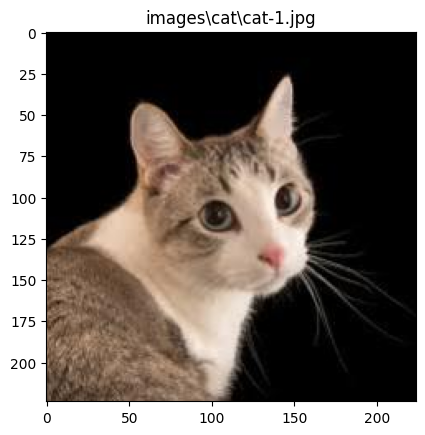

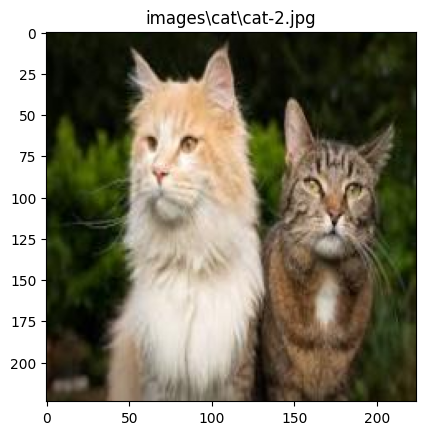

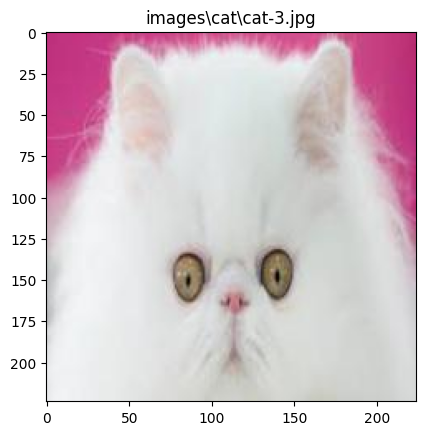

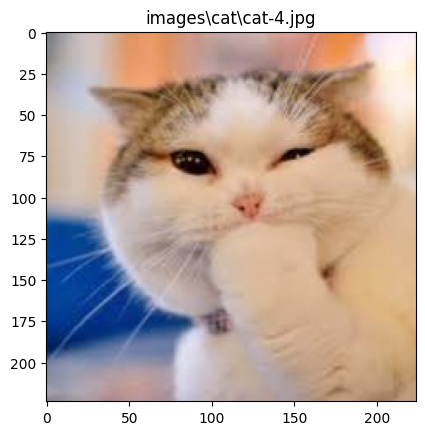

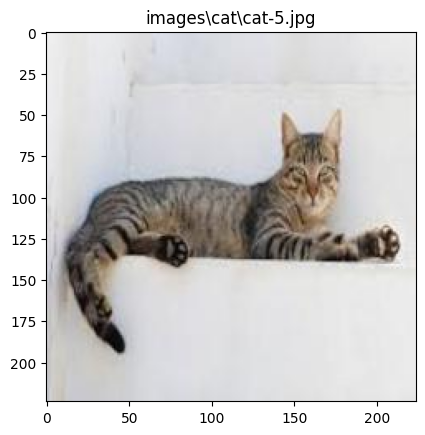

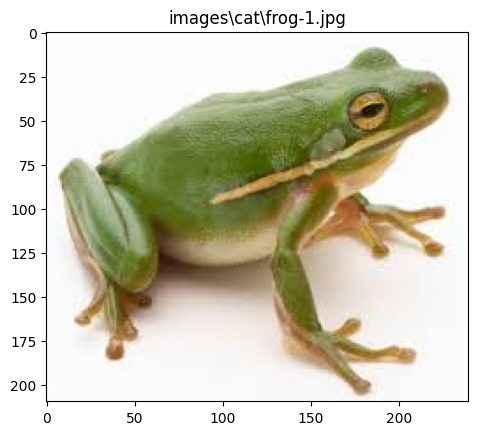

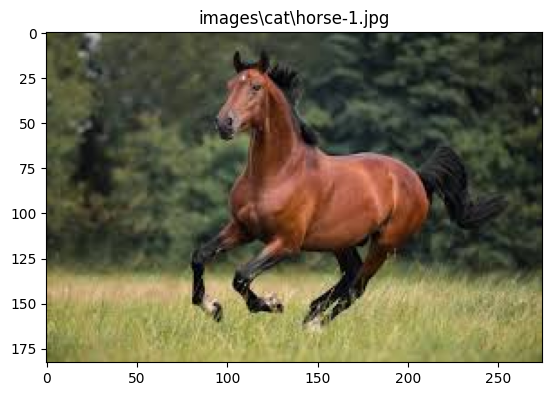

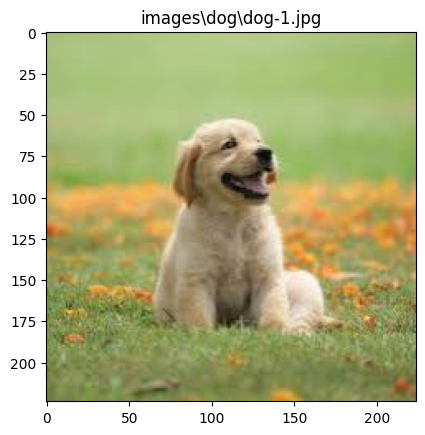

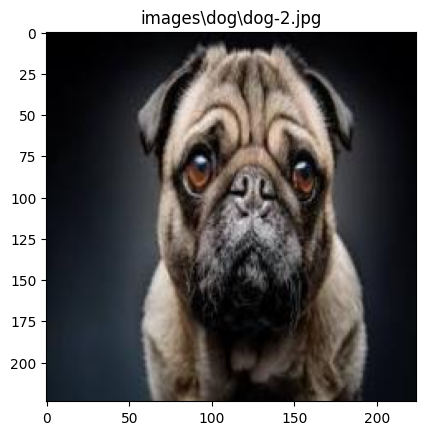

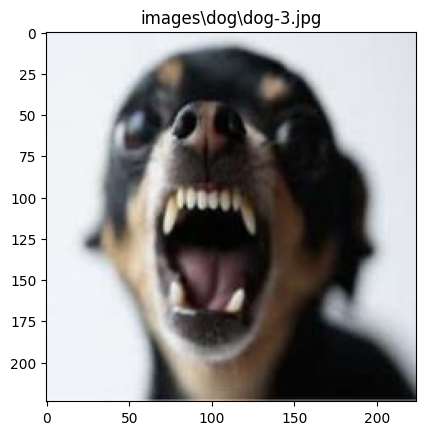

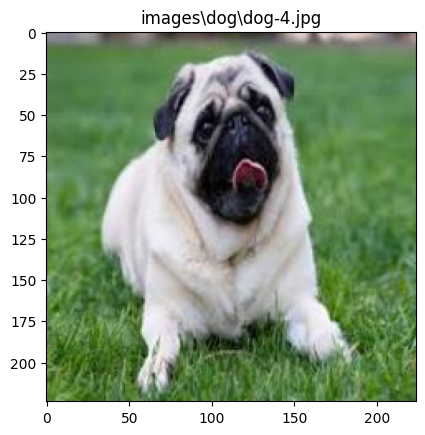

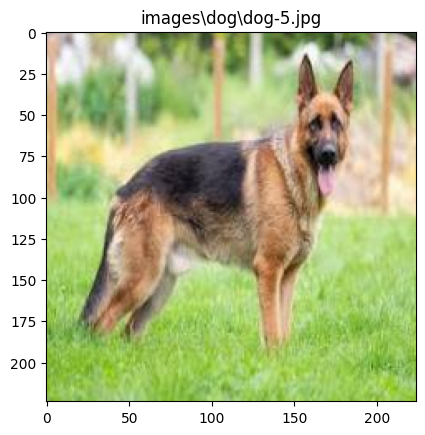

In [1]:
# View all images in our dataset / 查看我们数据集中的所有图像
import glob
import matplotlib.pyplot as plt
from PIL import Image

# Get a list of images with jpg / 获取所有 jpg 格式的图像列表
images_list = glob.glob("images/*/*jpg")

# Open each image / 打开每个图像
for image in images_list:
    # Set the title / 设置标题
    plt.title(image)
    # Open the image / 打开图像
    img = Image.open(image)
    plt.axis("on")
    plt.imshow(img)
    plt.show()

In [7]:
# Print our image list / 打印我们的图像列表
print(images_list)

['images\\cat\\cat-1.jpg', 'images\\cat\\cat-2.jpg', 'images\\cat\\cat-3.jpg', 'images\\cat\\cat-4.jpg', 'images\\cat\\cat-5.jpg', 'images\\dog\\dog-1.jpg', 'images\\dog\\dog-2.jpg', 'images\\dog\\dog-3.jpg', 'images\\dog\\dog-4.jpg', 'images\\dog\\dog-5.jpg']


In [6]:
# Remove images from our list that we dont want / 从列表中删除我们不想要的图像
# Example: Remove a specific image you reviewed and deemed bad / 示例：删除你审核并认为不好的特定图像
# images_list.remove("images/cat/bad_image.jpg")
# You can display the list to see which images you want to remove / 你可以显示列表看看你想删除哪些图像
images_list.remove('images\\cat\\frog-1.jpg')
images_list.remove('images\\cat\\horse-1.jpg')
print(images_list)

['images\\cat\\cat-1.jpg', 'images\\cat\\cat-2.jpg', 'images\\cat\\cat-3.jpg', 'images\\cat\\cat-4.jpg', 'images\\cat\\cat-5.jpg', 'images\\dog\\dog-1.jpg', 'images\\dog\\dog-2.jpg', 'images\\dog\\dog-3.jpg', 'images\\dog\\dog-4.jpg', 'images\\dog\\dog-5.jpg']


In [8]:
# We are using an annotations file lets write the final list to a csv with its class / 我们使用标注文件，将最终列表写入带有其类别的 csv 中
import os
import pandas as pd

data = []

for file_path in images_list:
    # Extract the class label from the path ie: dog or cat / 从路径中提取类别标签，例如：dog 或 cat
    label = os.path.basename(os.path.dirname(file_path))
    # Append path and label / 追加路径和标签
    data.append({"file_path": file_path, "label": label})

# Save DF as CSV file / 将 DataFrame 保存为 CSV 文件
df = pd.DataFrame(data)
df.to_csv("image_data.csv", index=False)

# Here we created our intitial annotations file / 这里我们创建了初始标注文件

### Create an initial PyTorch Dataset / 创建初始 PyTorch 数据集

Once our data is cleaned up and ready, we need to create an initial Dataset that consists of all eligible images.

一旦我们的数据被清理并准备好，我们需要创建一个包含所有符合条件的图像的初始数据集。

This is so we can split our data into Training, Validation and Testing subsets.

这样我们可以将数据分成训练、验证和测试子集。

In [9]:
import pandas as pd
from torch.utils.data import Dataset


class InitialDataset(Dataset):
    def __init__(self, annotations_file):
        self.img_labels = pd.read_csv(annotations_file)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = self.img_labels.iloc[idx, 0]
        label = self.img_labels.iloc[idx, 1]
        return img_path, label

In [10]:
# Create a PyTorch Dataset / 创建 PyTorch 数据集
dataset = InitialDataset(annotations_file='image_data.csv')

In [11]:
# Print the annoations / 打印标注
dataset.img_labels

,file_path,label
0,images\cat\cat-1.jpg,cat
1,images\cat\cat-2.jpg,cat
2,images\cat\cat-3.jpg,cat
3,images\cat\cat-4.jpg,cat
4,images\cat\cat-5.jpg,cat
5,images\dog\dog-1.jpg,dog
6,images\dog\dog-2.jpg,dog
7,images\dog\dog-3.jpg,dog
8,images\dog\dog-4.jpg,dog
9,images\dog\dog-5.jpg,dog


# Random Split / 随机分割

Review:

回顾：

The `random_split` function in PyTorch helps divide your dataset into different parts such as training, validation and testin sets, by randomly selecting samples for each part.

PyTorch 中的 `random_split` 函数通过为每个部分随机选择样本，帮助将数据集分成不同的部分，如训练、验证和测试集。

This is important because splitting data lets you train the model on one part and test it on another, helping you see how well the model performs on new, unseen data.

这很重要，因为分割数据可以让您在一部分上训练模型，在另一部分上测试它，帮助您了解模型在新的、看不见的数据上的表现如何。

Randomly splitting the data ensures each set has a good mix, making the model's evaluation more reliable.

随机分割数据可确保每个集合都有良好的混合，使模型的评估更可靠。

Data Splits:

数据分割：

**Training data** is the largest portion, and it's what the model learns from by finding patterns in the data.

**训练数据** 是最大的部分，模型通过在数据中查找模式来学习。

**Validation data** is used during training to tune the model's settings, helping prevent overfitting so the model doesn't just memorize the training data.

**验证数据** 在训练期间用于调整模型的设置，帮助防止过拟合，使模型不仅仅是记忆训练数据。

**Testing data** is used after training to check how well the model performs on completely new data. This setup ensures the model can make accurate predictions on data it hasn't seen before, making it more useful and reliable.

**测试数据** 在训练后用于检查模型在完全新数据上的表现。这种设置确保模型可以对它以前没有见过的数据做出准确的预测，使其更有用和可靠。

In [12]:
# Import random_split from PyTorch's data utilities
from torch.utils.data import random_split

In [13]:
# Define size of Training data from the full dataset 70% / 从完整数据集定义训练数据的大小 70%
train_size = int(0.7 * len(dataset))

In [14]:
# Define size of Validation data from the full dataset 15% / 从完整数据集定义验证数据的大小 15%
val_size = int(0.15 * len(dataset))

In [15]:
# Finally define the rest as test data 15% / 最后将其余部分定义为测试数据 15%
test_size = len(dataset) - train_size - val_size

In [16]:
# Create a training, validation and testing dataset by splitting the full dataset by size / 通过按大小分割完整数据集来创建训练、验证和测试数据集
# Here we use random_split / 这里我们使用 random_split
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [17]:
# Take a look at the outputs we get from the subsets / 查看我们从子集获得的输出
print(train_dataset.indices, val_dataset.indices, test_dataset.indices)

[9, 3, 2, 7, 6, 0, 1] [8] [5, 4]


The output of `random_split` PyTorch is a list of Subset objects, each representing a portion of the original dataset.

PyTorch 的 `random_split` 输出是 Subset 对象的列表，每个对象代表原始数据集的一部分。

We can use these lists of indexes to retrieve samples from our original dataset.

我们可以使用这些索引列表从原始数据集中检索样本。

In [18]:
# Compare the original dataset to our index / 将原始数据集与我们的索引进行比较
# Print the annotations / 打印标注
dataset.img_labels

,file_path,label
0,images\cat\cat-1.jpg,cat
1,images\cat\cat-2.jpg,cat
2,images\cat\cat-3.jpg,cat
3,images\cat\cat-4.jpg,cat
4,images\cat\cat-5.jpg,cat
5,images\dog\dog-1.jpg,dog
6,images\dog\dog-2.jpg,dog
7,images\dog\dog-3.jpg,dog
8,images\dog\dog-4.jpg,dog
9,images\dog\dog-5.jpg,dog


In [19]:
# Print the item in the dataset at the first index of the train_dataset / 打印数据集中train_dataset第一个索引处的项
dataset.img_labels.loc[train_dataset.indices[0]]
# We can do the same for other indexes and for validation datasets and testing datasets / 我们可以对其他索引以及验证数据集和测试数据集做同样的操作

file_path    images\dog\dog-5.jpg
label                         dog
Name: 9, dtype: object

# Data Versioning and Tracking / 数据版本控制和跟踪

As we covered in the video, there are multiple ways to version your data and we wont cover any particular method in this course.

如我们在视频中所述，有多种方法来对数据进行版本控制，在本课程中我们不会涵盖任何特定方法。

However, the reason we are covering this is because it is a best practice.

然而，我们涵盖这个的原因是因为这是一个最佳实践。

Versioning and tracking makes your work more reliable and allows you to reproduce results consistently, even if the data changes over time.

版本控制和跟踪使您的工作更可靠，并允许您即使数据随时间变化也能一致地重现结果。

In [20]:
# Lets write annotation files for each of our subsets of data. / 让我们为每个数据子集写注释文件。
# This method can be used for other forms of model training outside of images such as text, audio, etc / 此方法可用于图像外的其他形式的模型训练，如文本、音频等
import pandas as pd

data = []

# For each index in the training indices / 对于训练索引中的每个索引
for idx in train_dataset.indices:
    # Extract the file_path and the label from the original dataset / 从原始数据集中提取 file_path 和标签
    img_path = dataset.img_labels['file_path'].loc[idx]
    label = dataset.img_labels['label'].loc[idx]
    # Append path and label / 追加路径和标签
    data.append({"file_path": img_path, "label": label})

# Save DF as CSV file / 将 DataFrame 保存为 CSV 文件
df = pd.DataFrame(data)
df.to_csv("training_data.csv", index=False)

In [21]:
# Do the same thing for our validation and testing sets. / 为我们的验证和测试集做同样的事情。
import pandas as pd

data = []

# For each index in the validation indices / 对于验证索引中的每个索引
for idx in val_dataset.indices:
    # Extract the file_path and the label from the original dataset / 从原始数据集中提取 file_path 和标签
    img_path = dataset.img_labels['file_path'].loc[idx]
    label = dataset.img_labels['label'].loc[idx]
    # Append path and label / 追加路径和标签
    data.append({"file_path": img_path, "label": label})

# Save DF as CSV file / 将 DataFrame 保存为 CSV 文件
df = pd.DataFrame(data)
df.to_csv("validation_data.csv", index=False)

# For each index in the test indices / 对于测试索引中的每个索引
for idx in test_dataset.indices:
    # Extract the file_path and the label from the original dataset / 从原始数据集中提取 file_path 和标签
    img_path = dataset.img_labels['file_path'].loc[idx]
    label = dataset.img_labels['label'].loc[idx]
    # Append path and label / 追加路径和标签
    data.append({"file_path": img_path, "label": label})

# Save DF as CSV file / 将 DataFrame 保存为 CSV 文件
df = pd.DataFrame(data)
df.to_csv("testing_data.csv", index=False)

# Define Transformations / 定义转换

Lets go ahead and define transformations for our subsets of data.

让我们继续为我们的数据子集定义转换。

Remember that there is a possibility that training could have different transforms than validation. This is present a more diverse sample to the model during training.

请记住，有可能训练的转换与验证不同。这在训练期间为模型呈现更多样化的样本。

In [22]:
# Begin by import transforms / 首先导入 transforms
from torchvision.transforms import v2

In [23]:
# Training Pipeline / 训练流水线
import torch

train_transform = v2.Compose([
    v2.Resize((128, 128)), # Resize the image / 调整图像大小
    v2.RandomCrop(size=(75, 75)), # Random Crop / 随机裁剪
    v2.RandomHorizontalFlip(p=.7), # Randomly flip horizontally / 随机水平翻转
    # Convert to tensor / 转换为张量
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize / 规范化
])

In [24]:
# Validation Pipeline / 验证流水线
val_transform = v2.Compose([
    v2.Resize((128, 128)), # Resize to a fixed size / 调整为固定大小
    # Convert to tensor / 转换为张量
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize / 规范化
])

# Define Datasets and DataLoaders / 定义数据集和数据加载器

Now that we have subsets of our data and individual transformations, we can create PyTorch Datasets from our subsets of data and DataLoaders for those subsets to load them into our model.

现在我们拥有数据的子集和各个转换，我们可以从数据的子集创建 PyTorch 数据集，并为这些子集创建数据加载器，以将它们加载到我们的模型中。

In [25]:
# Lets begin by defining our Custom Dataset / 让我们首先定义我们的自定义数据集
import pandas as pd


class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform, target_transform):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = lambda y: target_transform[y]

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = Image.open(img_path)
        label = self.img_labels.iloc[idx, 1]
        # Transform the image / 转换图像
        image = self.transform(image)
        # Get the label / 获取标签
        label = self.target_transform(label)
        
        return image, label

In [26]:
# Create the label encoding / 创建标签编码
label_encoding = {"cat": 0, "dog": 1}

In [27]:
# Create a training dataset / 创建训练数据集
train_dataset = CustomImageDataset(
    annotations_file='training_data.csv', 
    img_dir="./", 
    transform=train_transform, 
    target_transform=label_encoding
)

In [28]:
# Display the training data / 显示训练数据
train_dataset.img_labels

,file_path,label
0,images\dog\dog-5.jpg,dog
1,images\cat\cat-4.jpg,cat
2,images\cat\cat-3.jpg,cat
3,images\dog\dog-3.jpg,dog
4,images\dog\dog-2.jpg,dog
5,images\cat\cat-1.jpg,cat
6,images\cat\cat-2.jpg,cat


In [29]:
# Label encoding / 标签编码
train_dataset.target_transform('dog')

1

In [30]:
# Transformations / 转换
train_dataset.transform

Compose(
      Resize(size=[128, 128], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomCrop(size=(75, 75), pad_if_needed=False, fill=0, padding_mode=constant)
      RandomHorizontalFlip(p=0.7)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [31]:
# Create the validation dataset / 创建验证数据集
val_dataset = CustomImageDataset(
    annotations_file='validation_data.csv', 
    img_dir="./", 
    transform=val_transform, 
    target_transform=label_encoding
)

In [32]:
# Show the transforms / 显示转换
val_dataset.transform

Compose(
      Resize(size=[128, 128], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [33]:
# Create the DataLoaders for each PyTorch Dataset / 为每个 PyTorch 数据集创建 DataLoader
# Import DataLoader / 导入 DataLoader
from torch.utils.data import DataLoader

In [34]:
# Create the training DataLoader / 创建训练 DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [35]:
# Iterate through and print the batch size / 遍历并打印批大小
features, labels = next(iter(train_loader))
print(f"Features shape: {features.size()}")

Features shape: torch.Size([7, 3, 75, 75])


In [36]:
# Create the Validation DataLoader NOTICE the False shuffle / 创建验证 DataLoader 注意 shuffle 为 False
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [37]:
# Iterate / 遍历
features, labels = next(iter(val_loader))
print(f"Features shape: {features.size()}")

Features shape: torch.Size([1, 3, 128, 128])


#### You are now ready to begin training a model! / 现在您可以开始训练模型了！